In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving online+retail.zip to online+retail.zip


In [4]:
import zipfile
import os

zip_file = list(uploaded.keys())[0]

with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall("online_retail_data")

print("ZIP file extracted successfully!")
print(os.listdir("online_retail_data"))

ZIP file extracted successfully!
['Online Retail.xlsx']


In [5]:
import os

for root, dirs, files_list in os.walk("online_retail_data"):
    for file in files_list:
        print(os.path.join(root, file))

online_retail_data/Online Retail.xlsx


In [6]:
df = pd.read_excel("online_retail_data/Online Retail.xlsx")

print("Dataset loaded successfully!")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Dataset loaded successfully!
Rows: 541909
Columns: 8


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [7]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Column names:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID            float64
Country                object
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

Duplicate rows:
5268


In [8]:
# Remove rows without Customer ID
df = df.dropna(subset=['CustomerID'])

# Remove duplicate rows
df = df.drop_duplicates()

# Remove cancelled transactions
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# Keep only positive quantities and prices
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

print("Data cleaning completed!")
print("Rows after cleaning:", df.shape[0])
print("Columns:", df.shape[1])

Data cleaning completed!
Rows after cleaning: 392692
Columns: 8


In [9]:
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

print("TotalPrice column created successfully!")
df[['Quantity', 'UnitPrice', 'TotalPrice']].head()

TotalPrice column created successfully!


,Quantity,UnitPrice,TotalPrice
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [10]:
print("Final dataset shape:", df.shape)

print("\nDate range:")
print(df['InvoiceDate'].min(), "to", df['InvoiceDate'].max())

print("\nNumber of unique customers:")
print(df['CustomerID'].nunique())

Final dataset shape: (392692, 9)

Date range:
2010-12-01 08:26:00 to 2011-12-09 12:50:00

Number of unique customers:
4338


In [11]:
# Set reference date as one day after the last transaction
reference_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

# Create RFM table
rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (reference_date - x.max()).days,
    'InvoiceNo': 'nunique',
    'TotalPrice': 'sum'
})

# Rename columns
rfm.columns = ['Recency', 'Frequency', 'Monetary']

print("RFM table created successfully!")
print("Number of customers:", rfm.shape[0])

rfm.head()

RFM table created successfully!
Number of customers: 4338


,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,7,4310.00
12348.0,75,4,1797.24
12349.0,19,1,1757.55
12350.0,310,1,334.40


In [12]:
rfm.describe()

,Recency,Frequency,Monetary
count,4338.000000,4338.000000,4338.000000
mean,92.536422,4.272015,2048.688081
std,100.014169,7.697998,8985.230220
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,306.482500
50%,51.000000,2.000000,668.570000
75%,142.000000,5.000000,1660.597500
max,374.000000,209.000000,280206.020000


In [13]:
# Select RFM features
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]

# Standardize the features
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)

print("RFM features standardized successfully!")
print("Shape of standardized data:", rfm_scaled.shape)

RFM features standardized successfully!
Shape of standardized data: (4338, 3)


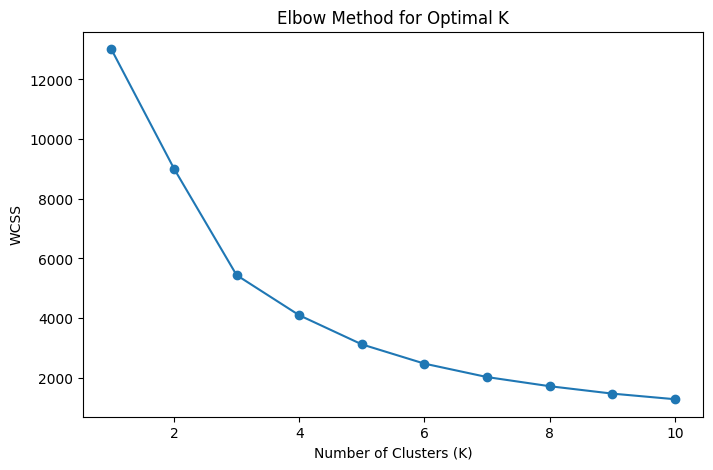

In [14]:
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS')
plt.title('Elbow Method for Optimal K')
plt.show()


In [15]:
# Apply K-Means clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)

# Fit the model
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

print("K-Means clustering completed successfully!")
print("Number of clusters:", rfm['Cluster'].nunique())

rfm.head()

K-Means clustering completed successfully!
Number of clusters: 4


,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,3
12347.0,2,7,4310.00,0
12348.0,75,4,1797.24,0
12349.0,19,1,1757.55,0
12350.0,310,1,334.40,1


In [16]:
cluster_profile = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()

cluster_profile = cluster_profile.round(2)

print("Cluster Profiles:")
cluster_profile

Cluster Profiles:


,Recency,Frequency,Monetary
Cluster,,,
0,43.70,3.68,1353.63
1,248.08,1.55,478.85
2,7.38,82.54,127187.96
3,15.50,22.33,12690.50


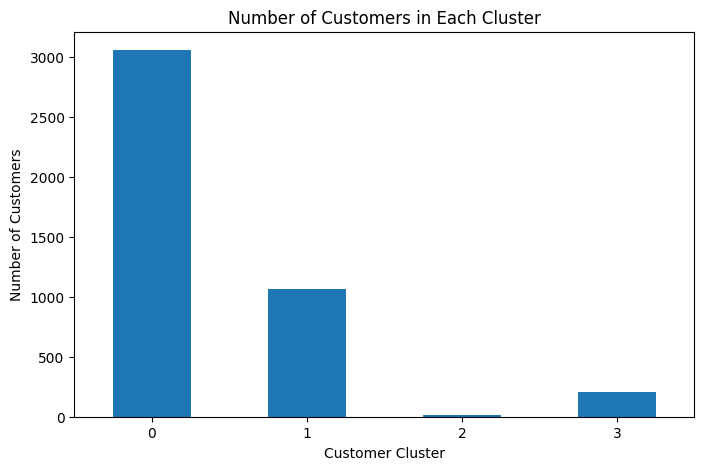

In [17]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
cluster_counts.plot(kind='bar')

plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Number of Customers in Each Cluster')
plt.xticks(rotation=0)
plt.show()

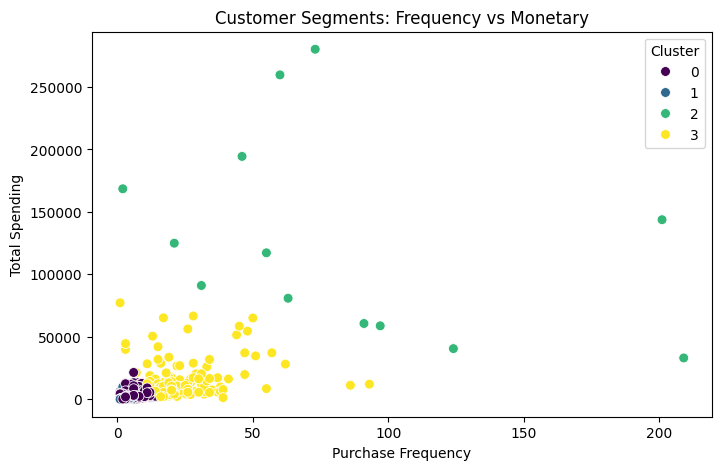

In [18]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Frequency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=50
)

plt.title('Customer Segments: Frequency vs Monetary')
plt.xlabel('Purchase Frequency')
plt.ylabel('Total Spending')
plt.legend(title='Cluster')
plt.show()

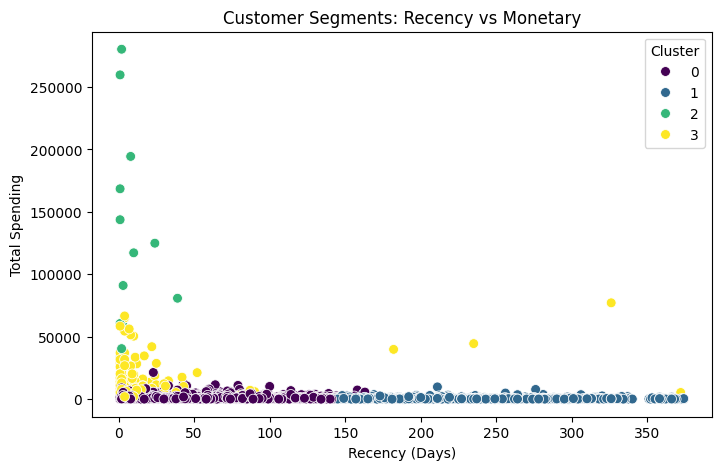

In [19]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=rfm,
    x='Recency',
    y='Monetary',
    hue='Cluster',
    palette='viridis',
    s=50
)

plt.title('Customer Segments: Recency vs Monetary')
plt.xlabel('Recency (Days)')
plt.ylabel('Total Spending')
plt.legend(title='Cluster')
plt.show()

## Customer Segment Interpretation

Based on the RFM cluster profiles, the customers can be divided into four segments:

### Cluster 0 – Regular Customers
These customers have moderate recency, purchase frequency, and spending.
They represent regular customers who purchase occasionally.

**Marketing Strategy:**
- Send personalized offers.
- Encourage repeat purchases.
- Provide product recommendations and bundle discounts.

### Cluster 1 – At-Risk / Inactive Customers
These customers have very high recency, low purchase frequency, and low spending.
They have not purchased for a long time and may be becoming inactive.

**Marketing Strategy:**
- Send reactivation campaigns.
- Offer special discounts or coupons.
- Use reminder emails to encourage them to return.

### Cluster 2 – High-Value Loyal Customers
These customers have very low recency, very high purchase frequency, and extremely high monetary value.
They are the most valuable customers in the dataset.

**Marketing Strategy:**
- Provide VIP rewards and loyalty benefits.
- Give early access to new products.
- Offer personalized premium promotions.

### Cluster 3 – Loyal Customers
These customers have low recency, good purchase frequency, and high spending.
They are active and valuable customers.

**Marketing Strategy:**
- Encourage continued loyalty.
- Provide loyalty points and member offers.
- Use cross-selling and personalized recommendations.

## Conclusion

Customer segmentation was performed using RFM analysis and the K-Means clustering algorithm.

The customers were divided into four distinct segments based on Recency, Frequency, and Monetary value.

The analysis identified regular customers, inactive or at-risk customers, loyal customers, and high-value loyal customers.

These segments can help businesses create targeted marketing strategies, improve customer retention, increase customer spending, and provide personalized offers.